In [1]:
# ── Bibliotecas padrão ──────────────────────────────────────────────────────
import os
import glob
import warnings
import random
warnings.filterwarnings('ignore')

# ── Manipulação de dados ────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualização ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# ── Processamento de imagens ────────────────────────────────────────────────
from PIL import Image, ImageFilter

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import img_to_array

# ── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)

# ── PSO (Particle Swarm Optimization) ──────────────────────────────────────
from pyswarms.discrete import BinaryPSO

# ── LIME (Local Interpretable Model-Agnostic Explanations) ─────────────────
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ── tf-keras-vis (disponível, mas Grad-CAM implementado manualmente por
#    compatibilidade com Keras 3 – ver Seção 6) ──────────────────────────────
# from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
# from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
# from tf_keras_vis.utils.scores import CategoricalScore

from xgboost import XGBClassifier

# ── Configurações gerais ────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow versão: {tf.__version__}')
print(f'Keras versão: {keras.__version__}')
print(f'GPUs disponíveis: {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1777141783.360760    7199 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777141783.368377    7199 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777141784.049897    7199 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777141787.121001    7199 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow versão: 2.21.0
Keras versão: 3.14.0
GPUs disponíveis: []


E0000 00:00:1777141791.269694    7199 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777141791.270971    7514 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777141791.327468    7199 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 1. Carregamento e Exploração dos Dados

Carregamos os caminhos das imagens e criamos DataFrames para facilitar a manipulação e visualização da distribuição das classes.

In [ ]:
# ── Definição dos caminhos base ─────────────────────────────────────────────
DATA_DIR   = '../data/'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
TEST_DIR   = os.path.join(DATA_DIR, 'test')
IMG_SIZE   = (224, 224)   # Tamanho padrão exigido pelo Xception
BATCH_SIZE = 32

# ── Coleta de caminhos via glob ─────────────────────────────────────────────
def collect_paths(base_dir):
    """Retorna DataFrame com colunas 'path' e 'label' para todas as imagens."""
    records = []
    for label in ['benign', 'malignant']:
        pattern = os.path.join(base_dir, label, '*.jpg')
        paths = glob.glob(pattern)
        for p in paths:
            records.append({'path': p, 'label': label})
    return pd.DataFrame(records)

df_train = collect_paths(TRAIN_DIR)
df_test  = collect_paths(TEST_DIR)

print('=== Conjunto de Treino ===')
print(df_train['label'].value_counts())
print(f'Total: {len(df_train)} imagens\n')

print('=== Conjunto de Teste ===')
print(df_test['label'].value_counts())
print(f'Total: {len(df_test)} imagens')

=== Conjunto de Treino ===
label
benign       1440
malignant    1197
Name: count, dtype: int64
Total: 2637 imagens

=== Conjunto de Teste ===
label
benign       360
malignant    300
Name: count, dtype: int64
Total: 660 imagens


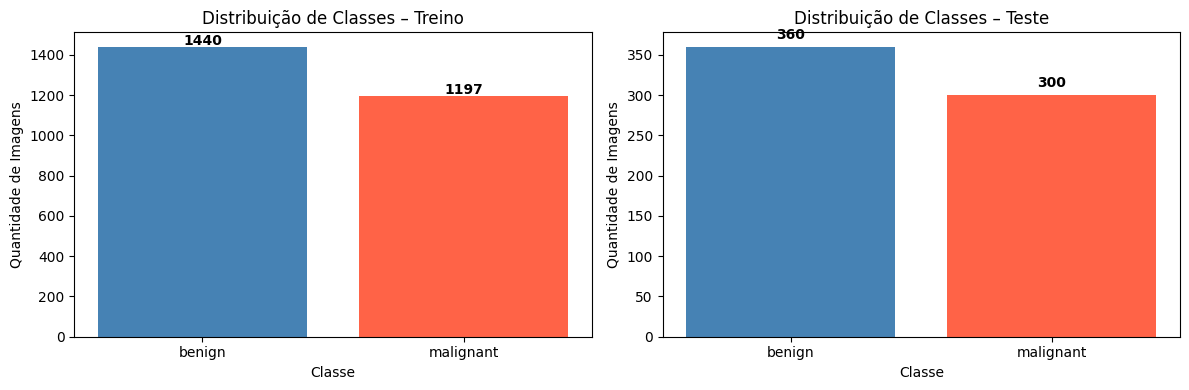

In [3]:
# ── Visualização da distribuição das classes ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, titulo) in zip(axes, [(df_train, 'Treino'), (df_test, 'Teste')]):
    contagens = df['label'].value_counts()
    ax.bar(contagens.index, contagens.values, color=['steelblue', 'tomato'])
    ax.set_title(f'Distribuição de Classes – {titulo}')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Quantidade de Imagens')
    for i, v in enumerate(contagens.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

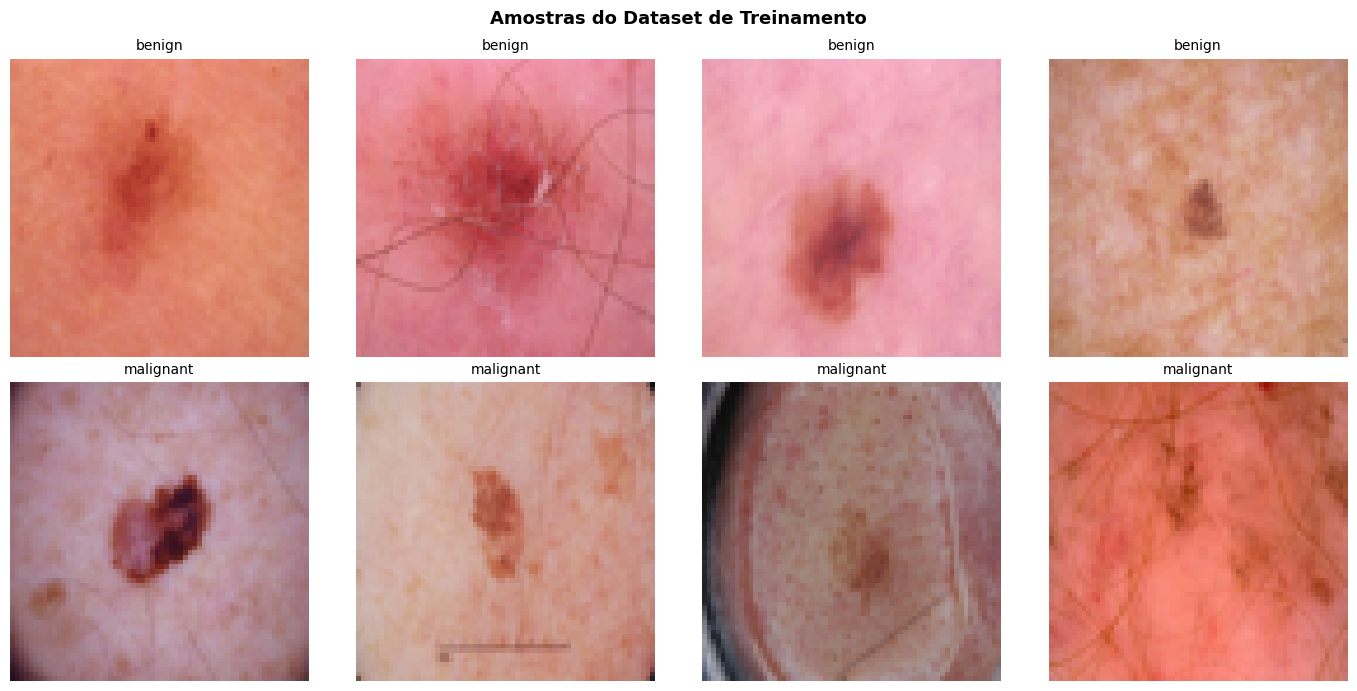

In [4]:
# ── Exibir amostras do dataset ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, label in enumerate(['benign', 'malignant']):
    amostras = df_train[df_train['label'] == label].sample(4, random_state=SEED)
    for j, (_, row) in enumerate(amostras.iterrows()):
        img = Image.open(row['path']).resize(IMG_SIZE)
        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{label}', fontsize=10)
        axes[i, j].axis('off')

plt.suptitle('Amostras do Dataset de Treinamento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Pre-processing data

This code performes few pre-processing steps on training & testing data like:
- split training into train-validation split
- add custom augmengtation layer(can be replaced with ImageDataGenerator) - here data is preety much balanced already so no need to do higher augmentation, only randomflip & randomzoom is performed.
- prepare tensor dataset and batches using tensorfloe.data.Dataset to fit in the training data

In [5]:
# ── Funções de carregamento e normalização ──────────────────────────────────
def load_image(path, size=IMG_SIZE):
    """Carrega imagem, redimensiona para 224×224 e normaliza para [0, 1]."""
    img = Image.open(path).convert('RGB').resize(size)
    return np.array(img, dtype=np.float32) / 255.0

# ── Funções de augmentação conforme o artigo ────────────────────────────────
def augment_rotation(img_array):
    """Rotação aleatória entre -180 e +180 graus."""
    angle = np.random.uniform(-180, 180)
    pil_img = Image.fromarray((img_array * 255).astype(np.uint8))
    rotated = pil_img.rotate(angle, resample=Image.BILINEAR)
    return np.array(rotated, dtype=np.float32) / 255.0

def augment_gaussian_blur(img_array, sigma=2):
    """Gaussian blur com sigma=2, conforme especificado no artigo."""
    pil_img = Image.fromarray((img_array * 255).astype(np.uint8))
    blurred = pil_img.filter(ImageFilter.GaussianBlur(radius=sigma))
    return np.array(blurred, dtype=np.float32) / 255.0

def augment_sharpen(img_array, amount=2, radius=1):
    """Sharpening com amount=2, radius=1, threshold=0, conforme artigo."""
    pil_img = Image.fromarray((img_array * 255).astype(np.uint8))
    sharpened = pil_img.filter(ImageFilter.UnsharpMask(radius=radius, percent=int(amount * 100), threshold=0))
    return np.array(sharpened, dtype=np.float32) / 255.0

print('Funções de augmentação definidas com sucesso.')

Funções de augmentação definidas com sucesso.


In [6]:
def build_augmented_dataset(df):
    """Constrói arrays X e y com imagens originais + 3 augmentações."""
    X_list, y_list = [], []
    label_map = {'benign': 0, 'malignant': 1}

    print(f'Processando {len(df)} imagens originais...')
    for idx, row in df.iterrows():
        img = load_image(row['path'])
        lbl = label_map[row['label']]

        # Imagem original
        X_list.append(img)
        y_list.append(lbl)

        # Augmentação 1: Rotação
        X_list.append(augment_rotation(img))
        y_list.append(lbl)

        # Augmentação 2: Gaussian blur
        X_list.append(augment_gaussian_blur(img))
        y_list.append(lbl)

        # Augmentação 3: Sharpening
        X_list.append(augment_sharpen(img))
        y_list.append(lbl)

        if (idx + 1) % 200 == 0:
            print(f'  {idx + 1}/{len(df)} imagens processadas...')

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    print(f'Dataset aumentado: {X.shape[0]} imagens ({np.sum(y==0)} benignas, {np.sum(y==1)} malignas)')
    return X, y

# ── Dataset de TESTE (sem augmentação) ──────────────────────────────────────
def build_test_dataset(df):
    """Constrói arrays X e y apenas com as imagens originais (sem augmentação)."""
    label_map = {'benign': 0, 'malignant': 1}
    X = np.array([load_image(p) for p in df['path']], dtype=np.float32)
    y = np.array([label_map[l] for l in df['label']], dtype=np.int32)
    print(f'Dataset de teste: {X.shape[0]} imagens ({np.sum(y==0)} benignas, {np.sum(y==1)} malignas)')
    return X, y

# Carrega dataset de teste
print('Carregando imagens de teste...')
X_test, y_test = build_test_dataset(df_test)

# Carrega dataset de treino AUMENTADO
print('\nCriando dataset de treino com augmentação...')
print('(Este processo pode levar alguns minutos)')
X_train_aug, y_train_aug = build_augmented_dataset(df_train)

Carregando imagens de teste...
Dataset de teste: 660 imagens (360 benignas, 300 malignas)

Criando dataset de treino com augmentação...
(Este processo pode levar alguns minutos)
Processando 2637 imagens originais...
  200/2637 imagens processadas...
  400/2637 imagens processadas...
  600/2637 imagens processadas...
  800/2637 imagens processadas...
  1000/2637 imagens processadas...
  1200/2637 imagens processadas...
  1400/2637 imagens processadas...
  1600/2637 imagens processadas...
  1800/2637 imagens processadas...
  2000/2637 imagens processadas...
  2200/2637 imagens processadas...
  2400/2637 imagens processadas...
  2600/2637 imagens processadas...
Dataset aumentado: 10548 imagens (5760 benignas, 4788 malignas)


In [ ]:
# ── Divisão treino/validação: 70% treino, 30% validação ────────────────────
# Conforme o artigo (Section 3): divisão 70:30 do conjunto de treino
X_train, X_val, y_train, y_val = train_test_split(
    X_train_aug, y_train_aug,
    test_size=0.30,
    random_state=SEED,
    stratify=y_train_aug
)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')

# ── Conversão para one-hot encoding (necessário para softmax) ────────────────
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   num_classes=2)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=2)

# # ── Criar tf.data.Dataset para treinamento eficiente ────────────────────────
ds_train = tf.data.Dataset.from_tensor_slices((X_train, y_train_oh))\
    .shuffle(buffer_size=2000, seed=SEED)\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((X_val, y_val_oh))\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

ds_test = tf.data.Dataset.from_tensor_slices((X_test, y_test_oh))\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

print('\nDatasets TensorFlow criados com sucesso.')

: 

## 3. Experimento 1: Xception com Transfer Learning

Conforme o artigo (Seção 3, Experimento 1), utilizamos o Xception pré-treinado no ImageNet com **todas as camadas congeladas** (100% frozen), que foi identificado como configuração ótima no estudo de ablação.

**Arquitetura adicionada ao topo:**
- Global Average Pooling
- Dense(512, ReLU)
- Dense(256, ReLU)
- Dense(2, Softmax)

In [ ]:
# ── Construção do modelo Xception com Transfer Learning ─────────────────────

# Base: Xception pré-treinado no ImageNet, sem a camada de classificação final
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar TODAS as camadas da base (100% frozen – configuração ótima do artigo)
base_model.trainable = False

# ── Camadas adicionadas ao topo ──────────────────────────────────────────────
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)   # training=False mantém BatchNorm em modo inferência
x       = layers.GlobalAveragePooling2D()(x)   # reduz para 2048 features no Xception
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(2,   activation='softmax')(x)

model_exp1 = Model(inputs, outputs, name='Xception_TransferLearning')

# ── Compilação ───────────────────────────────────────────────────────────────
model_exp1.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo das camadas treináveis
trainable     = sum(tf.size(w).numpy() for w in model_exp1.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model_exp1.non_trainable_weights)
print(f'Parâmetros treináveis:     {trainable:,}')
print(f'Parâmetros não treináveis: {non_trainable:,}')
model_exp1.summary()

In [ ]:
# ── Treinamento do Experimento 1 ─────────────────────────────────────────────
# O artigo treina por 5 épocas – o modelo atinge aprendizado ótimo nesse ponto.

EPOCHS = 5

history_exp1 = model_exp1.fit(
    ds_train,
    epochs=EPOCHS,
    validation_data=ds_val,
    verbose=1
)

print('\nTreinamento concluído!')

In [ ]:
# ── Curvas de aprendizado ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(history_exp1.history['accuracy'],     label='Treino',    marker='o')
axes[0].plot(history_exp1.history['val_accuracy'], label='Validação', marker='s')
axes[0].set_title('Acurácia – Experimento 1 (Xception)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True)

# Perda
axes[1].plot(history_exp1.history['loss'],     label='Treino',    marker='o')
axes[1].plot(history_exp1.history['val_loss'], label='Validação', marker='s')
axes[1].set_title('Perda – Experimento 1 (Xception)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ── Função auxiliar para calcular métricas detalhadas ───────────────────────
def compute_metrics(y_true, y_pred, y_prob, label='Experimento'):
    """
    Calcula e exibe: Acurácia, Sensibilidade (Recall maligno),
    Especificidade (Recall benigno), Precisão, F1-Score.
    """
    acc  = accuracy_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)
    # cm[0,0]=TN(benigno correto), cm[0,1]=FP, cm[1,0]=FN, cm[1,1]=TP(maligno correto)
    TN, FP, FN, TP = cm.ravel()
    sensibilidade  = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # recall maligno
    especificidade = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # recall benigno
    precisao       = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1             = 2 * precisao * sensibilidade / (precisao + sensibilidade) if (precisao + sensibilidade) > 0 else 0.0

    print(f'\n=== Métricas – {label} ===')
    print(f'  Acurácia:         {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Sensibilidade:    {sensibilidade:.4f} ({sensibilidade*100:.2f}%)')
    print(f'  Especificidade:   {especificidade:.4f} ({especificidade*100:.2f}%)')
    print(f'  Precisão:         {precisao:.4f} ({precisao*100:.2f}%)')
    print(f'  F1-Score:         {f1:.4f} ({f1*100:.2f}%)')

    # Matriz de confusão
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Matriz de Confusão – {label}')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Taxa de Falso Positivo')
    axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
    axes[1].set_title(f'Curva ROC – {label}')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return {
        'label': label,
        'acuracia': acc,
        'sensibilidade': sensibilidade,
        'especificidade': especificidade,
        'precisao': precisao,
        'f1': f1,
        'auc': roc_auc
    }

# ── Avaliação no conjunto de teste ──────────────────────────────────────────
y_prob_exp1 = model_exp1.predict(X_test, verbose=0)
y_pred_exp1 = np.argmax(y_prob_exp1, axis=1)

resultados = {}  # dicionário para consolidar resultados dos 3 experimentos
resultados['Exp1_Xception'] = compute_metrics(
    y_test, y_pred_exp1, y_prob_exp1, label='Experimento 1 – Xception TL'
)

## 4. Experimento 2: Extração de Features + Classificadores ML

Utilizamos o Xception como extrator de features (saída após o Global Average Pooling = **2048 features** no bloco de extração antes das camadas densas adicionadas). Em seguida, treinamos múltiplos classificadores de ML:

| Grupo | Classificador |
|-------|---------------|
| SVM | Linear, Medium Gaussian, Coarse Gaussian, Fine Gaussian |
| KNN | Fine, Medium, Coarse, Cosine, Weighted |
| Ensemble | Boosted Trees, Bagged Trees, Subspace Discriminant |

In [ ]:
# ── Construção do modelo extrator de features ────────────────────────────────
# Usamos a saída do GlobalAveragePooling da base Xception (2048-dim)
# IMPORTANTE: NÃO aplicar augmentação para extração de features

feature_extractor = Model(
    inputs=model_exp1.input,
    outputs=model_exp1.layers[2].output,  # saída do GlobalAveragePooling
    name='Xception_FeatureExtractor'
)

print(f'Dimensão das features extraídas: {feature_extractor.output_shape}')

# ── Carregamento das imagens ORIGINAIS de treino (sem augmentação) ──────────
print('Carregando imagens originais de treino para extração de features...')
X_train_orig = np.array([load_image(p) for p in df_train['path']], dtype=np.float32)
y_train_orig = np.array([0 if l == 'benign' else 1 for l in df_train['label']], dtype=np.int32)

# ── Extração de features ─────────────────────────────────────────────────────
print('Extraindo features do conjunto de treino...')
feat_train = feature_extractor.predict(X_train_orig, batch_size=32, verbose=1)

print('Extraindo features do conjunto de teste...')
feat_test = feature_extractor.predict(X_test, batch_size=32, verbose=1)

print(f'\nShape features treino: {feat_train.shape}')
print(f'Shape features teste:  {feat_test.shape}')

# ── Normalização das features (StandardScaler) ───────────────────────────────
scaler = StandardScaler()
feat_train_scaled = scaler.fit_transform(feat_train)
feat_test_scaled  = scaler.transform(feat_test)

# Divisão treino/validação para avaliação dos classificadores ML
feat_tr, feat_va, y_tr, y_va = train_test_split(
    feat_train_scaled, y_train_orig,
    test_size=0.30, random_state=SEED, stratify=y_train_orig
)
print(f'\nTreino ML: {feat_tr.shape[0]} | Validação ML: {feat_va.shape[0]}')

In [ ]:
# ── Definição dos classificadores ML ────────────────────────────────────────
# Baseado nos classificadores testados no artigo (Tabela de resultados)

classificadores = {
    # ── SVM variants ──────────────────────────────────────────────────────
    'SVM Linear':            SVC(kernel='linear',  C=1.0, probability=True, random_state=SEED),
    'SVM Medium Gaussian':   SVC(kernel='rbf',     C=1.0, gamma='scale', probability=True, random_state=SEED),
    'SVM Coarse Gaussian':   SVC(kernel='rbf',     C=0.1, gamma='auto',  probability=True, random_state=SEED),
    'SVM Fine Gaussian':     SVC(kernel='rbf',     C=10.0, gamma='scale', probability=True, random_state=SEED),

    # ── KNN variants ──────────────────────────────────────────────────────
    'KNN Fine (k=1)':        KNeighborsClassifier(n_neighbors=1),
    'KNN Medium (k=10)':     KNeighborsClassifier(n_neighbors=10),
    'KNN Coarse (k=100)':    KNeighborsClassifier(n_neighbors=100),
    'KNN Cosine':            KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    'KNN Weighted (k=10)':   KNeighborsClassifier(n_neighbors=10, weights='distance'),

    # ── Ensemble variants ─────────────────────────────────────────────────
    'Boosted Trees':         AdaBoostClassifier(n_estimators=100, random_state=SEED),
    'Bagged Trees':          BaggingClassifier(n_estimators=30, random_state=SEED),
    'Subspace Discriminant': BaggingClassifier(
                                 estimator=LinearDiscriminantAnalysis(),
                                 n_estimators=30,
                                 max_features=0.5,  # subspace = 50% das features aleatoriamente
                                 bootstrap=False,
                                 random_state=SEED
                             ),
}

print(f'Total de classificadores: {len(classificadores)}')

In [ ]:
# ── Treinamento e avaliação de todos os classificadores ─────────────────────
resultados_ml = []

for nome, clf in classificadores.items():
    print(f'Treinando: {nome}...')
    clf.fit(feat_tr, y_tr)

    y_pred = clf.predict(feat_test_scaled)
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(feat_test_scaled)
    else:
        y_prob = np.zeros((len(y_pred), 2))
        y_prob[np.arange(len(y_pred)), y_pred] = 1.0

    acc  = accuracy_score(y_test, y_pred)
    conf_mat = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = conf_mat.ravel()
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1   = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0.0
    try:
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
    except Exception:
        roc_auc = float('nan')

    resultados_ml.append({
        'Classificador': nome,
        'Acurácia (%)':       round(acc * 100, 2),
        'Sensibilidade (%)':  round(sens * 100, 2),
        'Especificidade (%)': round(spec * 100, 2),
        'Precisão (%)':       round(prec * 100, 2),
        'F1-Score (%)':       round(f1 * 100, 2),
        'AUC':                round(roc_auc, 4)
    })

# ── Tabela de resultados ─────────────────────────────────────────────────────
df_resultados_ml = pd.DataFrame(resultados_ml).sort_values('Acurácia (%)', ascending=False)
print('\n=== Resultados Experimento 2 – Classificadores ML ===')
print(df_resultados_ml.to_string(index=False))

In [ ]:
# ── Visualização detalhada do melhor classificador (Medium Gaussian SVM) ────
# Conforme artigo: Medium Gaussian SVM alcança 89.5% de acurácia

clf_melhor = classificadores['SVM Medium Gaussian']
y_pred_melhor = clf_melhor.predict(feat_test_scaled)
y_prob_melhor = clf_melhor.predict_proba(feat_test_scaled)

resultados['Exp2_SVM_MedGaussian'] = compute_metrics(
    y_test, y_pred_melhor, y_prob_melhor,
    label='Experimento 2 – SVM Medium Gaussian'
)

# ── Gráfico comparativo de acurácia ─────────────────────────────────────────
plt.figure(figsize=(14, 6))
cores = ['tomato' if v < 85 else ('gold' if v < 89 else 'steelblue')
         for v in df_resultados_ml['Acurácia (%)']]
bars = plt.barh(df_resultados_ml['Classificador'], df_resultados_ml['Acurácia (%)'], color=cores)
plt.xlabel('Acurácia (%)')
plt.title('Comparação de Classificadores ML – Experimento 2')
plt.axvline(x=89.5, color='red', linestyle='--', label='Referência artigo (89.5%)')
plt.legend()
for bar, val in zip(bars, df_resultados_ml['Acurácia (%)']):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Experimento 3: PSO + Subspace KNN

O **PSO (Particle Swarm Optimization)** é usado para seleção binária de features, reduzindo as ~2048 features para ~508 features relevantes.

**Parâmetros PSO (conforme artigo):**
- `n_particles = 30`
- `iterations = 100`
- `c1 = 0.5` (componente cognitivo)
- `c2 = 0.3` (componente social)
- `w = 0.9` (inércia)
- Função fitness: KNN (k=5) – minimiza `1 - acurácia`

In [ ]:
# ── PSO Binary Feature Selection ─────────────────────────────────────────────
# Usamos as features já normalizadas do Experimento 2

N_FEATURES = feat_tr.shape[1]  # dimensão das features (ex.: 2048)

# Divisão adicional treino/val para o PSO (dentro do conjunto de treino)
feat_pso_tr, feat_pso_va, y_pso_tr, y_pso_va = train_test_split(
    feat_tr, y_tr,
    test_size=0.20, random_state=SEED, stratify=y_tr
)

# ── Função de fitness ────────────────────────────────────────────────────────
def fitness_pso(particles):
    """
    Função de fitness para o PSO binário.
    Cada partícula é um vetor binário (0 ou 1) indicando quais features usar.
    Retorna o custo = 1 - acurácia (PSO minimiza).
    """
    costs = []
    for particle in particles:
        selected = np.where(particle == 1)[0]
        # Se nenhuma feature foi selecionada, custo máximo
        if len(selected) == 0:
            costs.append(1.0)
            continue
        # Treina KNN com k=5 nas features selecionadas
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(feat_pso_tr[:, selected], y_pso_tr)
        acc = accuracy_score(y_pso_va, knn.predict(feat_pso_va[:, selected]))
        costs.append(1.0 - acc)
    return np.array(costs)

# ── Configuração e execução do BinaryPSO ─────────────────────────────────────
print('Iniciando PSO para seleção de features...')
print(f'Espaço de busca: {N_FEATURES} features')
print('Parâmetros: n_particles=30, iterations=100, c1=0.5, c2=0.3, w=0.9')

options_pso = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 5, 'p': 2}

optimizer = BinaryPSO(
    n_particles=30,
    dimensions=N_FEATURES,
    options=options_pso
)

# Executar otimização (100 iterações)
best_cost, best_pos = optimizer.optimize(
    fitness_pso,
    iters=100,
    verbose=True
)

# ── Análise da solução encontrada ────────────────────────────────────────────
features_selecionadas = np.where(best_pos == 1)[0]
n_selecionadas = len(features_selecionadas)
print(f'\nFeatures selecionadas: {n_selecionadas} de {N_FEATURES} ({n_selecionadas/N_FEATURES*100:.1f}%)')
print(f'Custo mínimo (1 - acc): {best_cost:.4f}  →  Acurácia val: {(1-best_cost)*100:.2f}%')

In [ ]:
# ── Subspace KNN com as features selecionadas pelo PSO ───────────────────────
# Subspace KNN = BaggingClassifier com KNN de base, treinado em subconjuntos de features

feat_tr_sel   = feat_tr[:, features_selecionadas]
feat_test_sel = feat_test_scaled[:, features_selecionadas]

subspace_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=30,
    max_features=0.5,   # usar 50% das features selecionadas em cada estimador
    bootstrap=True,
    random_state=SEED
)

print('Treinando Subspace KNN com features selecionadas pelo PSO...')
subspace_knn.fit(feat_tr_sel, y_tr)

# Predição e probabilidades
y_pred_exp3 = subspace_knn.predict(feat_test_sel)
y_prob_exp3 = subspace_knn.predict_proba(feat_test_sel)

resultados['Exp3_PSO_SubspaceKNN'] = compute_metrics(
    y_test, y_pred_exp3, y_prob_exp3,
    label='Experimento 3 – PSO + Subspace KNN'
)

In [ ]:
# ── Curva de convergência do PSO ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(optimizer.cost_history, color='steelblue', linewidth=2)
plt.xlabel('Iteração')
plt.ylabel('Custo (1 - Acurácia)')
plt.title('Curva de Convergência do PSO – Seleção de Features')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Redução de features: {N_FEATURES} → {n_selecionadas}')
print(f'Taxa de redução: {(1 - n_selecionadas/N_FEATURES)*100:.1f}%')

## 6. Experimento 4: Plus: Baselin - Vanila CNN

This code builds and train Vanila CNN model, check validation and test accuracy and other performance parameters

In [ ]:
def vanila_cnn():

    model = Sequential([
        layers.Input(shape=(224, 224, 3), dtype=tf.float32),
        layers.Conv2D(16, kernel_size=3, activation='relu'),
        layers.MaxPool2D(pool_size=2, padding='valid'),
        layers.Conv2D(8, kernel_size=3, activation='relu'),
        layers.MaxPool2D(pool_size=2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu'),
        layers.Dense(2, activation='softmax')
    ], name='vanila_cnn_model')

    tf.random.set_seed(42)

    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )

    return model

In [ ]:
model_exp4 = vanila_cnn()

EPOCHS = 5

print(f"Iniciando treinamento do Experimento 4: {model_exp4.name}...")

history_exp4 = model_exp4.fit(
    ds_train,
    epochs=EPOCHS,
    validation_data=ds_val,
    verbose=1
)

print('\nTreinamento do Experimento 4 concluído!')

## 7. Experimento N: Ensemble Learning

In [ ]:
# Ou AdaBoostClassifier da sklearn
def get_meta_features(dataset):
    # Exp 1: Xception Softmax (Probabilidade da classe 1)
    pred_1 = model_exp1.predict(dataset)[:, 1]

    # Exp 2: MG-SVM (Muitos modelos de ML usam predict_proba)
    pred_2 = model_exp2.predict_proba(dataset_features)[:, 1]

    # Exp 3: PSO + Subspace KNN
    pred_3 = model_exp3.predict_proba(dataset_pso_features)[:, 1]

    # Exp 4: Vanilla CNN
    pred_4 = model_exp4.predict(dataset)[:, 1]

    X_meta = np.column_stack((pred_1, pred_2, pred_3, pred_4))
    return X_meta

X_meta_train = get_meta_features(ds_val)
y_meta_train = y_val_true

# 2. Gerar features para o teste final
X_meta_test = get_meta_features(ds_test)
y_meta_test = y_test_true

In [ ]:
# Opção 1: XGBoost (Geralmente mais robusto)
meta_model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3)
meta_model.fit(X_meta_train, y_meta_train)


# Predição final do Ensemble
ensemble_preds = meta_model.predict(X_meta_test)

## Técnicas XAI (Explainable AI)

Implementamos três técnicas de IA Explicável para interpretar as predições do modelo, conforme a Seção 6 do artigo:

1. **Grad-CAM (Gradient-weighted Class Activation Mapping):** Visualiza as regiões da imagem mais importantes para a classificação usando gradientes da última camada convolucional.

2. **LIME (Local Interpretable Model-Agnostic Explanations):** Pertuba pixels da imagem e verifica como a predição muda para identificar regiões relevantes.

3. **Occlusion Sensitivity:** Mascara sistematicamente partes da imagem e mede a queda na confiança da predição.

In [ ]:
# ── Seleção de imagens amostra para XAI ──────────────────────────────────────
# Escolhemos 2 imagens benignas e 2 malignas corretamente classificadas

def get_amostras_corretas(df, y_true, y_pred, label, n=2):
    """Retorna índices de amostras corretamente classificadas para determinada classe."""
    label_int = 0 if label == 'benign' else 1
    indices_label = df[df['label'] == label].index.tolist()
    # Mapear índice do df para posição no array
    idx_map = {orig: pos for pos, orig in enumerate(df.index)}
    corretos = [idx_map[i] for i in indices_label
                if idx_map.get(i) is not None
                and y_pred[idx_map[i]] == y_true[idx_map[i]]]
    return random.sample(corretos, min(n, len(corretos)))

# Índices no df_test
df_test_reset = df_test.reset_index(drop=True)
idx_benign    = df_test_reset[df_test_reset['label'] == 'benign'].sample(2, random_state=SEED).index.tolist()
idx_malignant = df_test_reset[df_test_reset['label'] == 'malignant'].sample(2, random_state=SEED).index.tolist()
idx_amostras  = idx_benign + idx_malignant

# Carregar imagens para XAI
imgs_xai   = X_test[idx_amostras]            # shape (4, 224, 224, 3)
labels_xai = ['Benigno', 'Benigno', 'Maligno', 'Maligno']

print(f'Imagens selecionadas para XAI: {len(imgs_xai)}')
print(f'Índices: {idx_amostras}')

# Visualizar as amostras
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, lbl in zip(axes, imgs_xai, labels_xai):
    ax.imshow(img)
    ax.set_title(f'Classe: {lbl}', fontsize=11)
    ax.axis('off')
plt.suptitle('Imagens Amostradas para Análise XAI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Grad-CAM (implementação manual, compatível com Keras 3 / TF 2.21) ─────────
# Nota: tf-keras-vis apresenta incompatibilidade com a API Funcional do Keras 3
# ao usar sub-modelos (como Xception encapsulado). Por isso, implementamos
# o Grad-CAM manualmente via tf.GradientTape — a mesma abordagem matemática do artigo.

def grad_cam_manual(model, img_array, class_idx):
    """
    Grad-CAM: gradientes da pontuação da classe em relação aos feature maps
    da última camada convolucional do Xception (7×7×2048).

    Retorna: heatmap 2D normalizado [0,1] com shape (224, 224).
    """
    base = model.layers[1]   # Backbone Xception (camadas convolucionais)
    img_tensor = tf.cast(img_array[np.newaxis, ...], tf.float32)

    with tf.GradientTape() as tape:
        # Passagem pelas camadas convolucionais → feature maps (1, 7, 7, 2048)
        conv_outputs = base(img_tensor, training=False)
        tape.watch(conv_outputs)

        # Aplicar as demais camadas do modelo manualmente (GAP → Dense → Softmax)
        x           = model.layers[2](conv_outputs)   # GlobalAveragePooling2D → (1, 2048)
        x           = model.layers[3](x)              # Dense(512, relu)
        x           = model.layers[4](x)              # Dense(256, relu)
        predictions = model.layers[5](x)              # Dense(2, softmax)
        class_score = predictions[:, class_idx]

    # Gradientes em relação aos feature maps da última conv
    grads = tape.gradient(class_score, conv_outputs)  # (1, 7, 7, 2048)

    # Média global dos gradientes (importância de cada canal)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (2048,)

    # Combinar canais ponderados pelos gradientes → heatmap espacial 7×7
    conv_np  = conv_outputs[0].numpy()                             # (7, 7, 2048)
    heatmap  = np.einsum('ijk,k->ij', conv_np, pooled_grads.numpy())  # (7, 7)

    # ReLU + normalização para [0, 1]
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Redimensionar para o tamanho original da imagem (224×224)
    heatmap_resized = np.array(
        Image.fromarray(heatmap).resize((224, 224), Image.BILINEAR)
    )
    return heatmap_resized

# ── Gerar predições para as amostras XAI ─────────────────────────────────────
preds_xai    = model_exp1.predict(imgs_xai, verbose=0)
classes_pred = np.argmax(preds_xai, axis=1)

# ── Visualização Grad-CAM ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (img, lbl, pred_cls) in enumerate(zip(imgs_xai, labels_xai, classes_pred)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'

    # Calcular heatmap Grad-CAM
    heatmap = grad_cam_manual(model_exp1, img, int(pred_cls))

    # Sobrepor heatmap à imagem original
    overlay      = cm.jet(heatmap)[..., :3]          # (224, 224, 3) RGB
    superimposed = np.clip(img * 0.6 + overlay * 0.4, 0, 1)

    # Linha 1: imagem original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original\nReal: {lbl}', fontsize=9)
    axes[0, i].axis('off')

    # Linha 2: Grad-CAM sobreposto
    axes[1, i].imshow(superimposed)
    axes[1, i].set_title(f'Grad-CAM\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM – Regiões Mais Relevantes para Classificação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── LIME (Local Interpretable Model-Agnostic Explanations) ───────────────────
# Perturba superpixels da imagem e analisa o impacto na predição

explainer_lime = lime_image.LimeImageExplainer(random_state=SEED)

def predict_fn_lime(images):
    """Função de predição compatível com LIME (entrada: array de imagens [0,1])."""
    imgs = np.array(images, dtype=np.float32)
    return model_exp1.predict(imgs, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (img, lbl, pred_cls) in enumerate(zip(imgs_xai, labels_xai, classes_pred)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'

    # Gerar explicação LIME
    explanation = explainer_lime.explain_instance(
        img,
        predict_fn_lime,
        top_labels=2,
        hide_color=0,
        num_samples=300  # reduzido para velocidade; artigo usa mais amostras
    )

    # Imagem com superpixels positivos (regiões que favorecem a classe predita)
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    # Imagem original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original\nReal: {lbl}', fontsize=9)
    axes[0, i].axis('off')

    # LIME overlay
    axes[1, i].imshow(mark_boundaries(temp, mask))
    axes[1, i].set_title(f'LIME\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('LIME – Superpixels Relevantes para Classificação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Occlusion Sensitivity ────────────────────────────────────────────────────
# Mascara sistematicamente regiões da imagem com uma janela deslizante
# e mede a queda na confiança da predição

def occlusion_sensitivity(model, img, target_class, patch_size=32, stride=16):
    """
    Calcula mapa de sensibilidade por oclusão.

    Parâmetros:
        model       : modelo Keras
        img         : imagem normalizada (H, W, 3)
        target_class: índice da classe de interesse
        patch_size  : tamanho da janela de oclusão (pixels)
        stride      : passo da janela

    Retorna:
        sensitivity_map: mapa 2D de quedas na confiança
    """
    H, W = img.shape[:2]
    sensitivity_map = np.zeros((H, W), dtype=np.float32)
    count_map       = np.zeros((H, W), dtype=np.float32)

    # Confiança base (sem oclusão)
    base_conf = model.predict(img[np.newaxis, ...], verbose=0)[0][target_class]

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            img_occluded = img.copy()
            img_occluded[y:y+patch_size, x:x+patch_size, :] = 0.5  # cinza médio
            conf_occluded = model.predict(img_occluded[np.newaxis, ...], verbose=0)[0][target_class]
            drop = base_conf - conf_occluded  # queda na confiança
            sensitivity_map[y:y+patch_size, x:x+patch_size] += drop
            count_map[y:y+patch_size, x:x+patch_size]       += 1

    count_map[count_map == 0] = 1
    return sensitivity_map / count_map

# ── Gerar e visualizar mapas de oclusão ──────────────────────────────────────
print('Calculando Occlusion Sensitivity (pode levar alguns minutos)...')

fig, axes = plt.subplots(3, 4, figsize=(18, 13))

for i, (img, lbl, pred_cls) in enumerate(zip(imgs_xai, labels_xai, classes_pred)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'

    occ_map = occlusion_sensitivity(model_exp1, img, target_class=pred_cls,
                                     patch_size=32, stride=16)

    # Linha 1: imagem original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original – {lbl}', fontsize=9)
    axes[0, i].axis('off')

    # Linha 2: mapa de oclusão
    axes[1, i].imshow(occ_map, cmap='hot')
    axes[1, i].set_title(f'Mapa Oclusão\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

    # Linha 3: sobreposição
    occ_norm = (occ_map - occ_map.min()) / (occ_map.max() - occ_map.min() + 1e-8)
    overlay  = img * 0.6 + plt.cm.hot(occ_norm)[..., :3] * 0.4
    axes[2, i].imshow(np.clip(overlay, 0, 1))
    axes[2, i].set_title('Sobreposição', fontsize=9)
    axes[2, i].axis('off')

plt.suptitle('Occlusion Sensitivity – Regiões Críticas para Classificação',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()